# Two arms learning to coordinate (in-phase / anti-phase)

A two-plant, two-controller setup inspired by **Tomassini et al. (2022, *iScience*), *Interpersonal
synchronization of movement intermittency*** — two people performing paced rhythmic finger
movements either *in-phase* (same direction) or *anti-phase* (opposite directions), using vision of
each other to coordinate.

Here:

- **Two separate plants** (`TwoDofArm`, 6 muscles each), each driven by **its own GRU controller**.
- Each controller sees: the coordination mode + a shared metronome clock, **its own proprioception**
  (delayed), **its own visual feedback** (endpoint, delayed), and the **partner's visual feedback**
  (the other arm's endpoint, delayed).
- **All feedback delays are independently controllable** (own proprioception, own vision, partner
  vision).
- **Joint task**: both endpoints oscillate left-right at the metronome pace, keeping the instructed
  relative phase (in-phase or anti-phase).

The dyadic environment lives in `MotorNetUtils/environment.py` (`DyadCoordination`).

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import motornet as mn
from MotorNetUtils.environment import DyadCoordination

device = torch.device("cpu")
torch.manual_seed(0)
np.random.seed(0)
print("motornet", mn.__version__)

motornet 0.3.0


## 1. Build the two plants and the dyadic task

Two identical 2-DoF arms. The `DyadCoordination` environment wraps both, sets the metronome pace,
samples a coordination mode per trial, and delivers each controller the cross-coupled, delayed
feedback. Tune the three delays (in seconds) to change the visuomotor lag — e.g. make the
**partner** vision more delayed than one's own, as in the paper's anti-phase / virtual-partner
manipulations.

In [21]:
eff = mn.effector.Effector(skeleton=mn.skeleton.TwoDofArm(), muscle=mn.muscle.ReluMuscle(), timestep=0.01)
muscles = [
    ([0, 1], [[0.05,  0.0], [0.12, 0.0]], 1000, "ext_01"),
    ([0, 1], [[-0.05,  0.0], [0.12, 0.0]], 1000, "flx_01"),
    ([1, 2], [[0.28,  0.0], [0.10, 0.0]], 600, "flx_12a"),
    ([1, 2], [[0.20,  0.0], [0.05, 0.0]], 600, "flx_12b"),
    ([1, 1, 2], [[0.2,  0.0], [0.32, -.02],  [0.13, 0.0]],  550, "ext_112"),
    ([0, 1, 2], [[0.08,  0.0], [0.32, -.01],  [0.13, 0.0]],  550, "ext_012"),
    #([1, 2], [[0.28, -0.03], [0.10, 0.0]], 600, "elb_ext"),
    #([0, 2], [[0.0,  0.03], [0.10, 0.0]],  500, "bi_flx"),
    #([0, 2], [[0.0, -0.03], [0.10, 0.0]],  500, "bi_ext"),
]
for fixation, coords, force, name in muscles:
    eff.add_muscle(path_fixation_body=fixation, path_coordinates=coords,
                max_isometric_force=force, name=name)

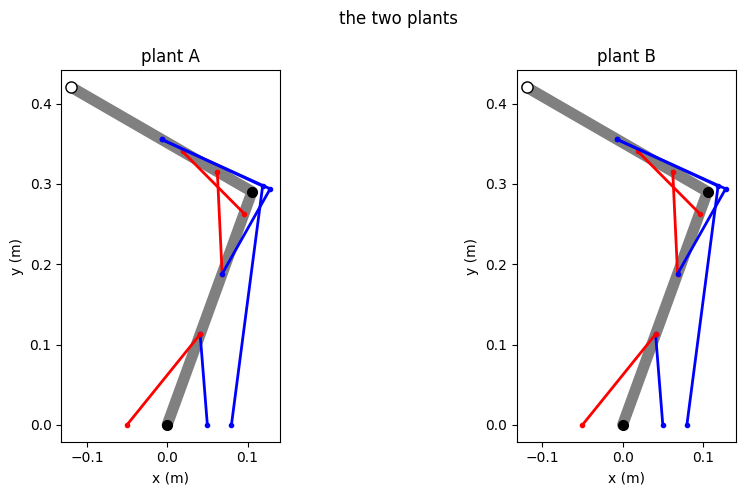

In [22]:
# display the plant (both arms are identical 2-DoF arms)
from MotorNetUtils.vis import draw_arm

lengths = [eff.skeleton.l1, eff.skeleton.l2]
q_show = ((eff.skeleton.pos_lower_bound + eff.skeleton.pos_upper_bound) / 2)
q_show = q_show.detach().cpu().numpy().ravel()   # mid-range posture (rad)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, title in zip(axes, ["plant A", "plant B"]):
    draw_arm(fig, ax, q_show, lengths, muscles)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
fig.suptitle("the two plants")
plt.tight_layout()
plt.show()


In [ ]:
env = DyadCoordination(
    eff, eff,
    freq=(0.1, 2),               # metronome frequency range (Hz), sampled per trial
    amp=(0.04, 0.4),              # oscillation amplitude range (m), sampled per trial
    max_ep_duration=(3.0, 12.0),   # episode duration range (s), sampled per episode
    modes=("in", "anti"),      # train both coordination modes
    proprioception_delay=0.02,  # own proprioception lag (s)
    own_vision_delay=0.10,      # own visual lag (s)
    partner_vision_delay=0.10,  # partner visual lag (s)
)

obs_dim_a, obs_dim_b = env.obs_dim
n_a, n_b = env.n_muscles
dt = env.dt
print("obs dim (a, b):", env.obs_dim, "| muscles (a, b):", env.n_muscles)
print("delay steps  prop / own-vision / partner-vision:",
      env._d_prop, env._d_self_vis, env._d_partner_vis, f"(dt={dt}s)")

obs dim (a, b): (19, 19) | muscles (a, b): (6, 6)
delay steps  prop / own-vision / partner-vision: 2 5 10 (dt=0.01s)


## 2. Two controllers + rollout

Each arm has its own `PolicyGRU`. They are trained **together** (one optimizer over both) so they
co-adapt — the only way to satisfy the relative-phase objective is to take the partner into account.

In [24]:
policy_a = mn.policy.PolicyGRU(obs_dim_a, 128, n_a, device=device)
policy_b = mn.policy.PolicyGRU(obs_dim_b, 128, n_b, device=device)
params = list(policy_a.parameters()) + list(policy_b.parameters())
optimizer = torch.optim.Adam(params, lr=1e-3)


def run_episode(batch_size, mode=None):
    """Roll out the dyad; return endpoints, targets, centres, actions and mode."""
    ha, hb = policy_a.init_hidden(batch_size), policy_b.init_hidden(batch_size)
    opts = {"batch_size": batch_size}
    if mode is not None:
        opts["mode"] = mode
    (oa, ob), info = env.reset(options=opts)
    ca, cb, ms = info["center_a"], info["center_b"], info["mode_sign"].flatten()
    ea, eb, ta, tb, aa_l, ab_l = [], [], [], [], [], []
    terminated = False
    while not terminated:
        aa, ha = policy_a(oa, ha)
        ab, hb = policy_b(ob, hb)
        (oa, ob), terminated, info = env.step((aa, ab))
        ea.append(info["endpoint_a"][:, None, :]); ta.append(info["target_a"][:, None, :])
        eb.append(info["endpoint_b"][:, None, :]); tb.append(info["target_b"][:, None, :])
        aa_l.append(aa[:, None, :]); ab_l.append(ab[:, None, :])
    cat = lambda L: torch.cat(L, dim=1)
    return dict(ea=cat(ea), eb=cat(eb), ta=cat(ta), tb=cat(tb),
                aa=cat(aa_l), ab=cat(ab_l), ca=ca, cb=cb, mode=ms)

## 3. Train

Loss = how well each endpoint tracks its (mode-dependent) target over the episode, plus a small
effort penalty. Gradient norm clipped to 1; step skipped on any non-finite gradient.

In [26]:
batch_size = 32
n_batches = 20000
losses = []

for b in range(n_batches):
    r = run_episode(batch_size)
    track = (((r["ea"] - r["ta"]) ** 2).sum(-1) + ((r["eb"] - r["tb"]) ** 2).sum(-1)).mean()
    effort = 1e-3 * ((r["aa"] ** 2).sum(-1) + (r["ab"] ** 2).sum(-1)).mean()
    loss = track + effort

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
    if all(torch.isfinite(p.grad).all() for p in params if p.grad is not None):
        optimizer.step()

    losses.append(loss.item())
    if (b + 1) % 25 == 0:
        print(f"batch {b + 1:4d} | loss {loss.item():.5f} (track {track.item():.5f})")

batch   25 | loss 0.18052 (track 0.18032)
batch   50 | loss 0.15246 (track 0.15224)
batch   75 | loss 0.15660 (track 0.15655)
batch  100 | loss 0.15187 (track 0.15182)
batch  125 | loss 0.13300 (track 0.13296)
batch  150 | loss 0.14670 (track 0.14663)
batch  175 | loss 0.15919 (track 0.15915)
batch  200 | loss 0.15902 (track 0.15896)
batch  225 | loss 0.14386 (track 0.14386)
batch  250 | loss 0.14127 (track 0.14127)
batch  275 | loss 0.13883 (track 0.13883)
batch  300 | loss 0.10799 (track 0.10799)
batch  325 | loss 0.13584 (track 0.13584)
batch  350 | loss 0.12008 (track 0.12008)
batch  375 | loss 0.14069 (track 0.14069)
batch  400 | loss 0.10823 (track 0.10823)
batch  425 | loss 0.10838 (track 0.10838)
batch  450 | loss 0.08334 (track 0.08334)
batch  475 | loss 0.09398 (track 0.09398)
batch  500 | loss 0.09103 (track 0.09103)
batch  525 | loss 0.07783 (track 0.07783)
batch  550 | loss 0.07826 (track 0.07826)
batch  575 | loss 0.06615 (track 0.06614)
batch  600 | loss 0.05643 (track 0

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(5, 3))
plt.plot(losses)
plt.xlabel("batch"); plt.ylabel("loss"); plt.title("training")
plt.tight_layout(); plt.show()

## 4. Did they coordinate?

Plot the left-right displacement of each arm's endpoint over time, for an **in-phase** and an
**anti-phase** episode. In-phase: the two traces overlap (move together). Anti-phase: they mirror
(one goes right while the other goes left).

In [ ]:
with torch.no_grad():
    res = {"in": run_episode(1, mode="in"), "anti": run_episode(1, mode="anti")}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, mode in zip(axes, ["in", "anti"]):
    r = res[mode]
    T = r["ea"].shape[1]
    t = np.arange(T) * dt
    dA = (r["ea"][0, :, 0] - r["ca"][0, 0]).numpy()
    dB = (r["eb"][0, :, 0] - r["cb"][0, 0]).numpy()
    tgtA = (r["ta"][0, :, 0] - r["ca"][0, 0]).numpy()
    ax.plot(t, tgtA, "--", color="0.7", lw=1.5, label="metronome")
    ax.plot(t, dA, color="tab:blue", lw=2, label="arm A")
    ax.plot(t, dB, color="tab:red", lw=2, label="arm B")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{mode}-phase"); ax.set_xlabel("time (s)")
axes[0].set_ylabel("left-right displacement (m)")
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# Coordination view: arm-B vs arm-A displacement. In-phase -> points on the y=x diagonal;
# anti-phase -> on the y=-x diagonal.
with torch.no_grad():
    big = {"in": run_episode(8, mode="in"), "anti": run_episode(8, mode="anti")}

plt.figure(figsize=(4.5, 4.5))
for mode, color in [("in", "tab:blue"), ("anti", "tab:red")]:
    r = big[mode]
    dA = (r["ea"][..., 0] - r["ca"][:, None, 0]).numpy().ravel()
    dB = (r["eb"][..., 0] - r["cb"][:, None, 0]).numpy().ravel()
    plt.scatter(dA, dB, s=4, alpha=0.3, color=color, label=f"{mode}-phase")
lim = 0.07
plt.plot([-lim, lim], [-lim, lim], "k--", lw=0.8)
plt.plot([-lim, lim], [lim, -lim], "k:", lw=0.8)
plt.xlabel("arm A displacement (m)"); plt.ylabel("arm B displacement (m)")
plt.gca().set_aspect("equal"); plt.legend(); plt.title("relative coordination")
plt.tight_layout(); plt.show()

## 5. Things to try

- **Manipulate the visuomotor delays** in the env constructor (`proprioception_delay`,
  `own_vision_delay`, `partner_vision_delay`) and retrain — e.g. a large `partner_vision_delay`
  makes anti-phase coordination harder, echoing the paper's finding that anti-phase entails a larger
  effective "error dead-zone".
- **Ablate the partner feedback** (set `partner_vision_delay` very large, or zero out the last two
  observation entries inside the policy input) to test how much the cross-coupling actually helps.
- **Asymmetric / unidirectional** coupling (a "virtual partner"): give only one arm access to the
  other's vision, reproducing the paper's leader/follower asymmetry.
- Train a single mode (`modes="in"` or `modes="anti"`) for cleaner, faster convergence.